In [1]:
from pathlib import Path
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from mne import io
from mne import Epochs
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import balanced_accuracy_score
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torch.optim as optim
from braindecode.models import EEGNetv4

In [2]:
import torch
print(torch.__version__)
print("MPS available?", torch.backends.mps.is_available())

2.7.1
MPS available? True


### Config — paths & processing constants  

All hard-coded parameters live in one place so you (or a colleague) can
re-run the notebook on another machine by editing a single cell.

* **paths** – BIDS root and sub-folders inside `derivatives/`
* **data**  – recording constants reused later (montage, sfreq, etc.)

In [3]:
CONFIG = dict(
    paths = dict(
        bids_root   = Path("../bids_dataset"),
        annot_dir   = Path("../bids_dataset/derivatives/annotated"),
        deep_dir    = Path("../bids_dataset/derivatives/deep"),
        timing_csv  = Path("../audio-timeline.csv"),
    ),
    data = dict(
        sfreq       = 125.0,                      # Hz
        eeg_ch      = ["Fp1","Fp2","C3","C4","T7","T8",
                       "O1","O2","F3","F4","Fz","Pz","P3","P4"],
        n_blocks    = 20,
    ),
    model = dict(
        cv_folds    = 5,            # number of StratifiedGroupKFold splits
    ),
)

# create necessary directories
for path in CONFIG["paths"].values():
    if path.suffix == "":  # skip CSV
        path.mkdir(parents=True, exist_ok=True)

print("Notebook-06 CONFIG defined and directories created 🚀")

Notebook-06 CONFIG defined and directories created 🚀


## 1. Dataset Structure

In this section, we load all annotated FIF blocks and verify the integrity and shape of the data. Each block is read from disk with its pre-processed channels and annotations, ensuring all expected blocks (0–19) are available and correctly formatted.

We check:

- That all blocks (0–19) are loaded with the correct number of channels and samples.
- The consistency of data shape and duration across blocks.

In [4]:
# Load all annotated EEG blocks into a dictionary
raws = {}
block_ids = range(CONFIG['data']['n_blocks'])

for block_id in block_ids:
    fname = CONFIG['paths']['annot_dir'] / f'blk{block_id:02d}_annot_raw.fif'
    raws[block_id] = io.read_raw_fif(fname, preload=True, verbose='ERROR')
    data = raws[block_id].get_data()
    print(f"Loaded block {block_id:02d}: {data.shape[0]} channels × {data.shape[1]} samples, {raws[block_id].times[-1]:.2f} s")

# Quick check: all expected blocks loaded
assert len(raws) == CONFIG['data']['n_blocks'], "Mismatch in number of blocks loaded"

# Print a short summary for confirmation
print(f"\nAll {len(raws)} blocks loaded. Example block keys: {list(raws.keys())[:4]}")

Loaded block 00: 15 channels × 16331 samples, 130.64 s
Loaded block 01: 15 channels × 16553 samples, 132.42 s
Loaded block 02: 15 channels × 16553 samples, 132.42 s
Loaded block 03: 15 channels × 16553 samples, 132.42 s
Loaded block 04: 15 channels × 16553 samples, 132.42 s
Loaded block 05: 15 channels × 16553 samples, 132.42 s
Loaded block 06: 15 channels × 16553 samples, 132.42 s
Loaded block 07: 15 channels × 16553 samples, 132.42 s
Loaded block 08: 15 channels × 16553 samples, 132.42 s
Loaded block 09: 15 channels × 16553 samples, 132.42 s
Loaded block 10: 15 channels × 16553 samples, 132.42 s
Loaded block 11: 15 channels × 16553 samples, 132.42 s
Loaded block 12: 15 channels × 16553 samples, 132.42 s
Loaded block 13: 15 channels × 16553 samples, 132.42 s
Loaded block 14: 15 channels × 16553 samples, 132.42 s
Loaded block 15: 15 channels × 16553 samples, 132.42 s
Loaded block 16: 15 channels × 16553 samples, 132.42 s
Loaded block 17: 15 channels × 16553 samples, 132.42 s
Loaded blo

In [5]:
eeg_ch_names = CONFIG['data']['eeg_ch']
all_ch_names = raws[0].ch_names
eeg_picks = [all_ch_names.index(ch) for ch in eeg_ch_names]
n_channels = len(eeg_picks)

print("EEG picks:", eeg_picks)
print("EEG channel names:", [all_ch_names[i] for i in eeg_picks])
print("Number of EEG channels:", n_channels)

EEG picks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
EEG channel names: ['Fp1', 'Fp2', 'C3', 'C4', 'T7', 'T8', 'O1', 'O2', 'F3', 'F4', 'Fz', 'Pz', 'P3', 'P4']
Number of EEG channels: 14


In [6]:
# 1.2. Sliding Window Extraction (Respecting BAD_intro & Phrase Labels)

window_length_s = 2.0
window_hop_s = 0.5
sfreq = raws[0].info['sfreq']
window_samples = int(window_length_s * sfreq)
window_hop_samples = int(window_hop_s * sfreq)

all_windows = []

for block_id, raw in raws.items():
    # Collect all phrase and BAD_intro annotations
    annots = raw.annotations
    onset_s = annots.onset
    duration_s = annots.duration
    desc = annots.description

    # Build intervals for BAD_intro
    bad_mask = np.zeros(int(raw.n_times), dtype=bool)
    for onset, dur, label in zip(onset_s, duration_s, desc):
        if label == "BAD_intro":
            idx_start = int(onset * sfreq)
            idx_end = int((onset + dur) * sfreq)
            bad_mask[idx_start:idx_end] = True

    # Find all phrase onsets & labels
    phrase_onsets = []
    phrase_labels = []
    for onset, label in zip(onset_s, desc):
        if label.startswith("phrase/"):
            phrase_onsets.append(onset)
            phrase_labels.append(int(label.split("/")[1]))
    phrase_onsets = np.array(phrase_onsets)
    phrase_labels = np.array(phrase_labels)

    # Generate sliding windows over the whole block
    t_centers = np.arange(window_length_s/2, raw.times[-1] - window_length_s/2, window_hop_s)
    for t_center in t_centers:
        center_sample = int(t_center * sfreq)
        # Skip window if its center falls in a BAD_intro
        if bad_mask[center_sample]:
            continue
        # Find latest phrase onset ≤ t_center
        possible_idx = np.where(phrase_onsets <= t_center)[0]
        if len(possible_idx) == 0:
            continue  # No phrase label yet for this window
        phrase_idx = possible_idx[-1]
        label = phrase_labels[phrase_idx]
        # Compute window start (make sure in bounds)
        t_start = t_center - window_length_s/2
        start_sample = int(t_start * sfreq)
        if start_sample < 0 or (start_sample + window_samples) > raw.n_times:
            continue
        all_windows.append({
            "block_id": block_id,
            "start_sample": start_sample,
            "center_sample": center_sample,
            "label": label,
            "t_center": t_center,
        })

print("Checking window lengths for each block...")
for w in all_windows:
    block_id = w['block_id']
    raw = raws[block_id]
    seg = raw.get_data(picks=eeg_picks, start=w['start_sample'], stop=w['start_sample'] + window_samples)
    if seg.shape != (len(eeg_picks), window_samples):
        print(f"Bad window: block {block_id}, start {w['start_sample']} (shape {seg.shape})")

windows_df = pd.DataFrame(all_windows)

print(f"Extracted {len(windows_df)} windows from {len(raws)} blocks.")
print(windows_df.head())


Checking window lengths for each block...
Extracted 4177 windows from 20 blocks.
   block_id  start_sample  center_sample  label  t_center
0         0          1500           1625      1      13.0
1         0          1562           1687      1      13.5
2         0          1625           1750      1      14.0
3         0          1687           1812      1      14.5
4         0          1750           1875      1      15.0


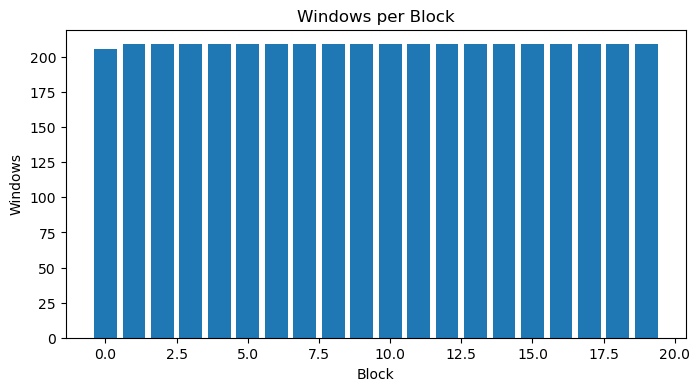

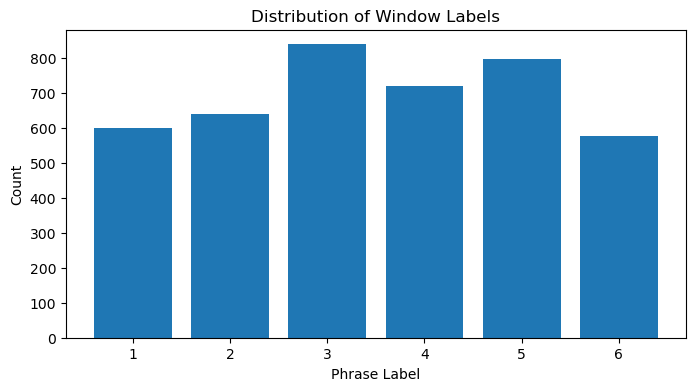

Window counts per block:
 block_id
0     206
1     209
2     209
3     209
4     209
5     209
6     209
7     209
8     209
9     209
10    209
11    209
12    209
13    209
14    209
15    209
16    209
17    209
18    209
19    209
Name: count, dtype: int64

Label distribution:
 label
1    600
2    640
3    840
4    720
5    798
6    579
Name: count, dtype: int64


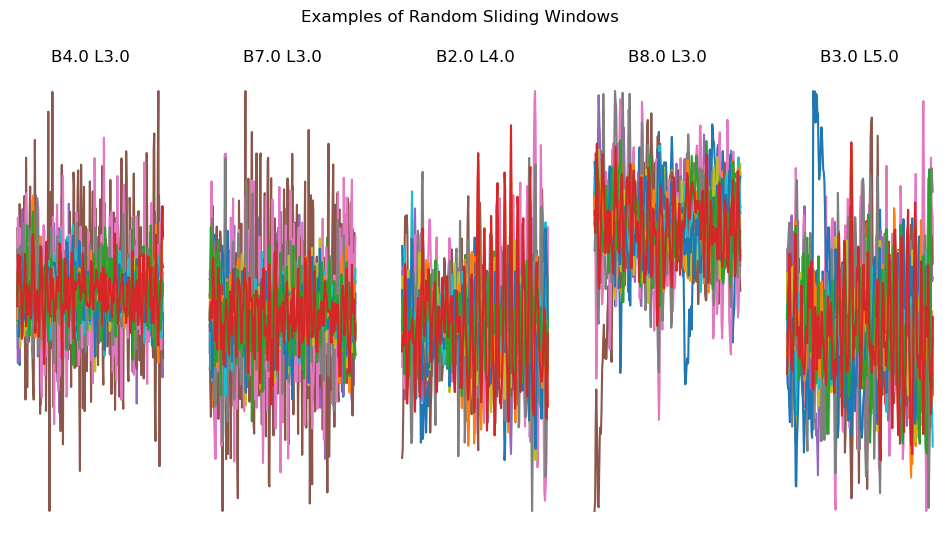

In [7]:
# 1.3. Window/Label Distribution Summary & Visual QC

# Distribution of windows per block
block_counts = windows_df['block_id'].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.bar(block_counts.index, block_counts.values)
plt.xlabel('Block')
plt.ylabel('Windows')
plt.title('Windows per Block')
plt.show()

# Distribution of labels
label_counts = windows_df['label'].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel('Phrase Label')
plt.ylabel('Count')
plt.title('Distribution of Window Labels')
plt.show()

print("Window counts per block:\n", block_counts)
print("\nLabel distribution:\n", label_counts)

# Quick plot of 5 random windows for QC
np.random.seed(42)
sample_idx = np.random.choice(len(windows_df), 5, replace=False)
plt.figure(figsize=(12,6))
for i, idx in enumerate(sample_idx, 1):
    row = windows_df.iloc[idx]
    block_id = row['block_id']
    start = row['start_sample']
    raw = raws[block_id]
    seg = raw.get_data(picks=eeg_picks, start=int(row['start_sample']), stop=int(row['start_sample']) + window_samples)
    plt.subplot(1,5,i)
    plt.plot(seg.T)
    plt.title(f"B{block_id} L{row['label']}")
    plt.axis('off')
plt.suptitle("Examples of Random Sliding Windows")
plt.show()

## 2. Labels and Groups

We extract sliding 2 s windows (with 0.5 s overlap) across each block, skipping intervals labeled as BAD_intro. For each window, the label is set to the most recent phrase marker preceding the window center.

We create a DataFrame indexing every window by:

- Block of origin (block_id)
- Window start and center (in samples and seconds)
- Assigned phrase label (1–6)

We confirm:

- The total number of windows and their distribution across blocks.
- The distribution of labels for quality control.

Counts of each label per block:
label   1   2   3   4   5   6
group                        
0      30  32  42  36  38  28
1      30  32  42  36  40  29
2      30  32  42  36  40  29
3      30  32  42  36  40  29
4      30  32  42  36  40  29
5      30  32  42  36  40  29
6      30  32  42  36  40  29
7      30  32  42  36  40  29
8      30  32  42  36  40  29
9      30  32  42  36  40  29
10     30  32  42  36  40  29
11     30  32  42  36  40  29
12     30  32  42  36  40  29
13     30  32  42  36  40  29
14     30  32  42  36  40  29
15     30  32  42  36  40  29
16     30  32  42  36  40  29
17     30  32  42  36  40  29
18     30  32  42  36  40  29
19     30  32  42  36  40  29


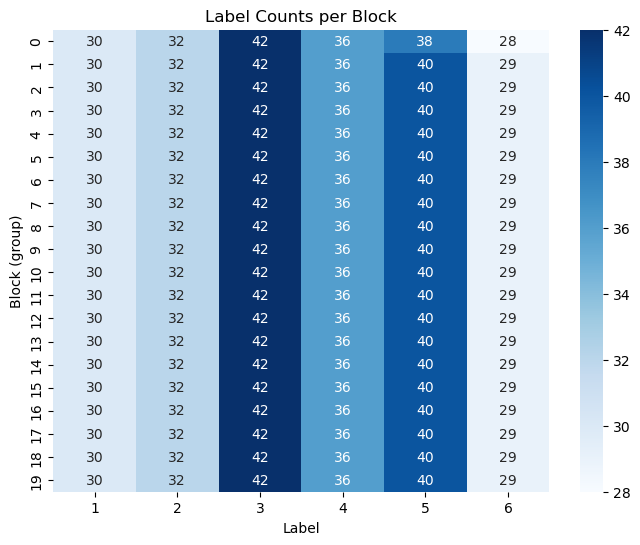

Number of missing (block, label) pairs: 0


In [ ]:
# 2b. Confirming Labels and Groups

# Add a "group" column as an alias for block_id (for clarity)
windows_df["group"] = windows_df["block_id"]

# Table: counts of each label per group (block)
pivot = pd.pivot_table(windows_df, index="group", columns="label", aggfunc="size", fill_value=0)

print("Counts of each label per block:")
print(pivot)

# Visualize as heatmap (optional)
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Label Counts per Block")
plt.xlabel("Label")
plt.ylabel("Block (group)")
plt.show()

# Quick assertion: all labels present in most blocks
n_missing = (pivot == 0).sum().sum()
print(f"Number of missing (block, label) pairs: {n_missing}")


## 3. Split Strategy

In this section, we use StratifiedGroupKFold to partition the extracted sliding windows into training, validation, and test splits. This strategy preserves the balance of phrase labels across splits while ensuring that all windows from a given block (recording session) remain grouped together. This is essential to avoid data leakage and to maintain a realistic out-of-sample evaluation.

We proceed as follows:

- The group column (block index) is used to keep all windows from the same block in a single split.
- The label column ensures each split maintains a similar class distribution.
- We assign split labels (train, val, test) to each window in the DataFrame for downstream processing.
- We visually inspect the label distribution within each split to verify balance and exclusivity.

This approach ensures robust, reproducible model evaluation without temporal or subject leakage.

Train blocks: [2, 3, 4, 7, 8, 9, 12, 13, 14, 17, 18, 19]
Val blocks: [0, 5, 10, 15]
Test blocks: [1, 6, 11, 16]


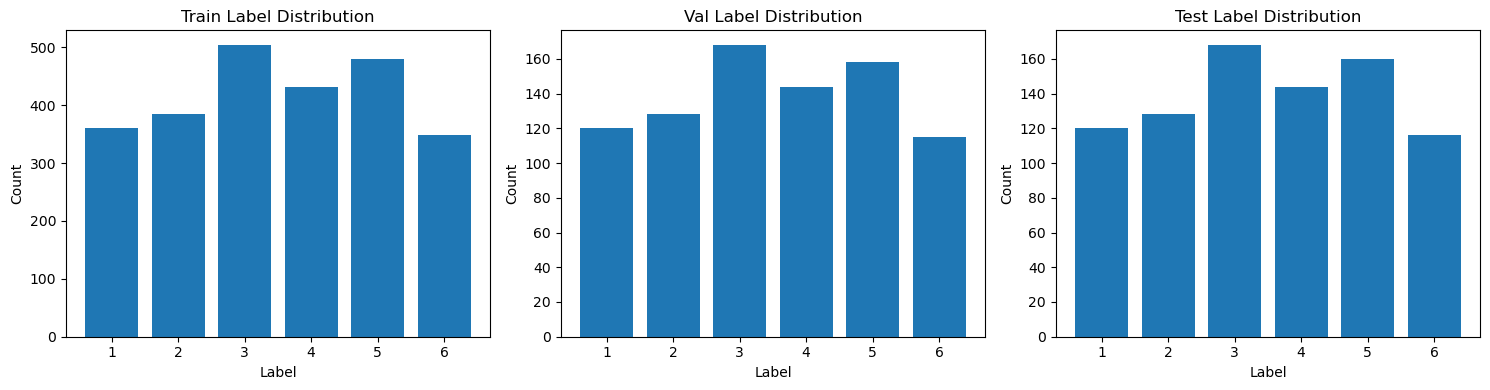

In [9]:
# 3. Split Strategy: StratifiedGroupKFold

# Prepare y and groups for splitting
y = windows_df["label"].values
groups = windows_df["group"].values

# Define the splitter
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Assign split labels
split_labels = np.empty(len(windows_df), dtype="<U8")
for i, (trainval_idx, test_idx) in enumerate(sgkf.split(np.zeros(len(y)), y, groups)):
    # For this project, let's use the first split: test = fold 0, val = fold 1, train = others
    # Get a further validation split from trainval if desired, or use folds 0/1 as test/val
    if i == 0:
        # Find which blocks are in test set
        test_blocks = set(windows_df.iloc[test_idx]["group"])
        # Use next fold for validation
        # Find blocks not in test
        trainval_blocks = set(windows_df["group"]) - test_blocks
        # Mask for trainval
        trainval_mask = windows_df["group"].isin(trainval_blocks)
        y_tv = windows_df.loc[trainval_mask, "label"].values
        groups_tv = windows_df.loc[trainval_mask, "group"].values
        # Second split: validation
        sgkf_val = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=43)
        for j, (train_idx, val_idx) in enumerate(sgkf_val.split(np.zeros(len(y_tv)), y_tv, groups_tv)):
            if j == 0:
                train_blocks = set(windows_df.loc[trainval_mask].iloc[train_idx]["group"])
                val_blocks = set(windows_df.loc[trainval_mask].iloc[val_idx]["group"])
                break
        break

# Now assign labels
split_labels[:] = "train"
split_labels[windows_df["group"].isin(val_blocks)] = "val"
split_labels[windows_df["group"].isin(test_blocks)] = "test"
windows_df["split"] = split_labels

# Confirm group exclusivity
for s in ["train", "val", "test"]:
    blocks = set(windows_df[windows_df["split"] == s]["group"])
    print(f"{s.capitalize()} blocks: {sorted(blocks)}")
assert len(set.intersection(*(set(windows_df[windows_df["split"] == s]["group"]) for s in ["train", "val", "test"]))) == 0, "Block overlap detected!"

# Visualize label balance
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, ["train", "val", "test"]):
    counts = windows_df[windows_df["split"] == split]["label"].value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{split.capitalize()} Label Distribution")
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 4. Normalization (Z-Score)

In this section, we compute per-channel mean and standard deviation using only the training windows. We then apply a z-score normalization to all windows, using these training-derived parameters for the validation and test sets as well.

**Procedure:**

- Select only windows assigned to the train split from the DataFrame.
- For each training window, load the corresponding EEG segment and concatenate them across all training blocks.
- Compute the mean and standard deviation for each channel, resulting in one mean and one std per channel.
- Normalize each window (across all splits) by subtracting the training mean and dividing by the training std, channel-wise.

This approach ensures that no information from the validation or test sets "leaks" into the normalization parameters, preserving a fair model evaluation.

We check the resulting normalized values for correctness by inspecting their distributions.

In [10]:
print("Channel names:", raws[0].ch_names)
print("Channel types:", raws[0].get_channel_types())

Channel names: ['Fp1', 'Fp2', 'C3', 'C4', 'T7', 'T8', 'O1', 'O2', 'F3', 'F4', 'Fz', 'Pz', 'P3', 'P4', 'stim']
Channel types: ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']


In [11]:
eeg_picks = [i for i, t in enumerate(raws[0].get_channel_types()) if t == 'eeg']
print("EEG picks:", eeg_picks)
print("Number of EEG channels:", len(eeg_picks))

EEG picks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Number of EEG channels: 14


In [12]:
# 4a. Compute Per-Channel Mean and Std on Training Windows

# Parameters
n_channels = len(eeg_picks)
window_samples = int(2.0 * sfreq)

# Select only train windows
train_df = windows_df[windows_df['split'] == 'train']

# Concatenate all training segments (channels x samples x windows)
train_segments = []
for i, row in train_df.iterrows():
    raw = raws[row['block_id']]
    seg = raw.get_data(picks=eeg_picks, start=int(row['start_sample']), stop=int(row['start_sample']) + window_samples)
    train_segments.append(seg)
train_data = np.stack(train_segments, axis=2)  # shape: channels x samples x windows

# Reshape to (channels, total_samples)
train_data_reshaped = train_data.reshape(n_channels, -1)

# Compute mean and std for each channel
channel_mean = train_data_reshaped.mean(axis=1)  # shape: (channels,)
channel_std = train_data_reshaped.std(axis=1)

print("Training set channel means:\n", channel_mean)
print("Training set channel stds:\n", channel_std)
print("Train data shape (channels x samples x windows):", train_data.shape)


Training set channel means:
 [ 7.83587261e-10  8.74145499e-10 -1.79862905e-10 -1.63295279e-10
 -2.60521475e-10  3.24612209e-10 -2.79933022e-10 -2.76384090e-10
 -5.81658913e-11 -8.45758985e-11 -2.60191865e-11 -2.07433349e-10
 -2.33773580e-10 -2.12380350e-10]
Training set channel stds:
 [1.58368158e-07 9.75456314e-08 1.08835557e-07 1.12722342e-07
 3.65372074e-07 5.25686702e-07 2.35666124e-07 1.75468460e-07
 1.25164368e-07 1.17216804e-07 1.24696301e-07 1.38150011e-07
 1.32763860e-07 1.38013066e-07]
Train data shape (channels x samples x windows): (14, 250, 2508)


In [14]:
# 4b. Apply Z-Score Normalization to All Windows

# Function for quick normalization
def normalize_segment(seg, mean, std):
    # seg: shape channels x samples
    return (seg - mean[:, None]) / std[:, None]

# Example: apply normalization to the first five windows and print means/stds
for idx in range(5):
    row = windows_df.iloc[idx]
    raw = raws[row['block_id']]
    seg = raw.get_data(picks=eeg_picks, start=int(row['start_sample']), stop=int(row['start_sample']) + window_samples)
    seg_norm = normalize_segment(seg, channel_mean, channel_std)
    print(f"Window {idx}: mean (per channel) after norm: {seg_norm.mean(axis=1)}")
    print(f"Window {idx}: std (per channel) after norm: {seg_norm.std(axis=1)}")


Window 0: mean (per channel) after norm: [ 0.02113896 -0.03235403  0.0218534   0.00741848 -0.00467766 -0.00326169
  0.02360968  0.00299342  0.01306876 -0.00483695 -0.02450255 -0.00343936
 -0.00966437 -0.01686151]
Window 0: std (per channel) after norm: [0.82361657 1.22212207 0.87008643 0.74529964 0.41439997 0.519516
 0.92053561 1.04649063 0.91843424 0.83400586 0.91135756 1.03113608
 0.98860942 1.05564204]
Window 1: mean (per channel) after norm: [ 0.0206563   0.04303078  0.00809419 -0.05203454  0.00448102 -0.00632426
  0.00516414 -0.01916353  0.04862314 -0.00253508  0.06563654 -0.02807649
  0.00430281 -0.06750939]
Window 1: std (per channel) after norm: [0.77363088 1.08711234 0.83786305 0.73234805 0.42065735 0.52026243
 0.95749589 1.04472135 0.88759165 0.83190385 0.88990672 0.84267124
 0.9189961  0.90803217]
Window 2: mean (per channel) after norm: [-0.04494808  0.02921437  0.01040253  0.05432377 -0.00392544 -0.00960433
 -0.02391258 -0.02096787 -0.02135707  0.022149   -0.00287216  0.03

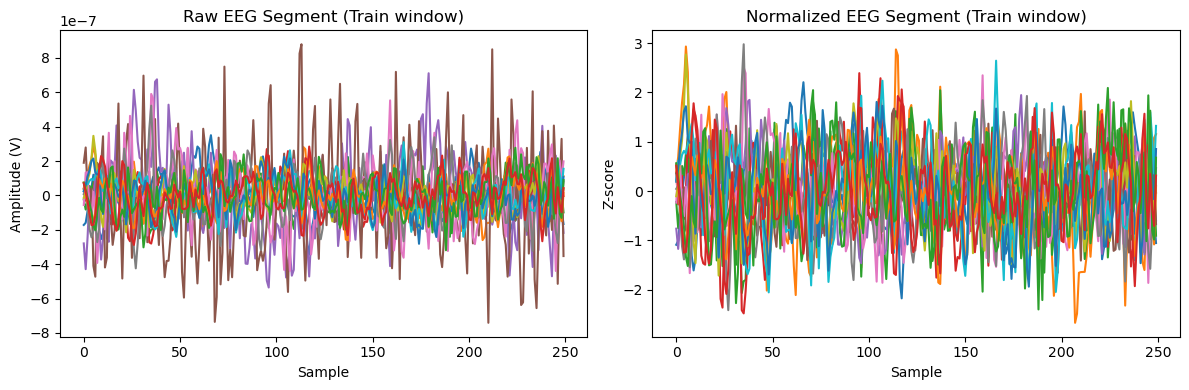

In [ ]:
# 4c. Visual Check: Distribution Before/After Normalization

# Pick a random training window
rand_idx = train_df.sample(1, random_state=0).index[0]
row = windows_df.loc[rand_idx]
raw = raws[row['block_id']]
seg = raw.get_data(picks=eeg_picks, start=int(row['start_sample']), stop=int(row['start_sample']) + window_samples)
seg_norm = normalize_segment(seg, channel_mean, channel_std)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(seg.T)
plt.title("Raw EEG Segment (Train window)")
plt.xlabel("Sample")
plt.ylabel("Amplitude (V)")

plt.subplot(1,2,2)
plt.plot(seg_norm.T)
plt.title("Normalized EEG Segment (Train window)")
plt.xlabel("Sample")
plt.ylabel("Z-score")

plt.tight_layout()
plt.show()


## 5. Class Imbalance and Loss Weights

In this section, we address the natural class imbalance present in the dataset: some phrase labels are more frequent than others due to experimental design and windowing strategy.

To ensure that the model does not become biased toward the majority classes, we:

- Compute the frequency of each class in the training split only.
- Calculate inverse-frequency weights so that minority classes receive higher penalty during training.
- Pass these weights to the loss function (e.g., PyTorch’s CrossEntropyLoss), which amplifies the contribution of under-represented classes to the training objective.

We visualize:
- The distribution of class frequencies in the training set.
- The corresponding class weights derived for the loss function.

This approach helps balance the learning process and encourages the model to perform well on all classes, not just the most common ones.

In [16]:
# 5. Class Imbalance: Compute Class Weights
# Only use the train split!
train_labels = windows_df.loc[windows_df["split"] == "train", "label"].values

# Calculate class frequencies (labels should be 1-based)
classes, counts = np.unique(train_labels, return_counts=True)
print("Train set class frequencies:")
for c, n in zip(classes, counts):
    print(f"Label {c}: {n} windows")

# Compute inverse-frequency weights
freqs = counts / counts.sum()
inv_freq = 1.0 / freqs
class_weights = inv_freq / inv_freq.sum() * len(classes)  # Normalize so sum = n_classes

# Prepare weights tensor for CrossEntropyLoss (zero-based index)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Class weights (to use in CrossEntropyLoss):", class_weights)


Train set class frequencies:
Label 1: 360 windows
Label 2: 384 windows
Label 3: 504 windows
Label 4: 432 windows
Label 5: 480 windows
Label 6: 348 windows
Class weights (to use in CrossEntropyLoss): [1.13860596 1.06744308 0.81328997 0.9488383  0.85395447 1.17786823]


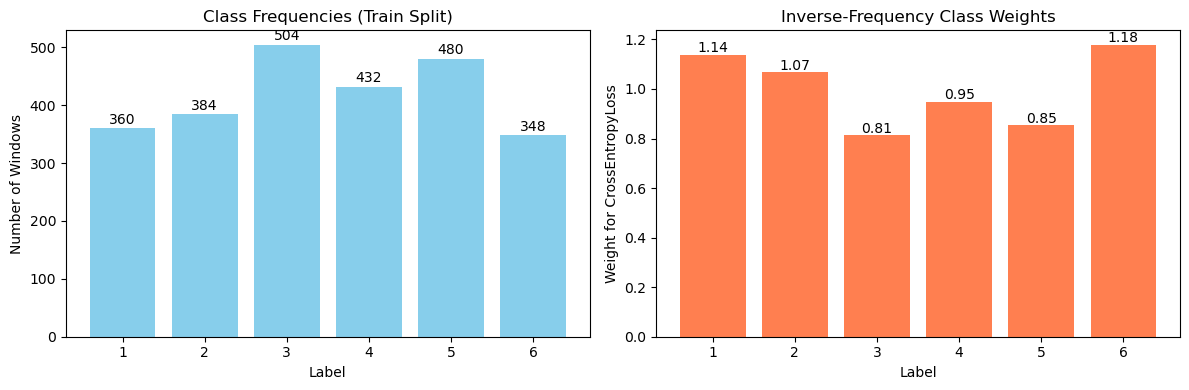

In [17]:
labels = [1, 2, 3, 4, 5, 6]
freqs = counts
weights = class_weights

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Frequencies
axes[0].bar(labels, freqs, color='skyblue')
axes[0].set_title("Class Frequencies (Train Split)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Number of Windows")
for i, v in enumerate(freqs):
    axes[0].text(labels[i], v + 8, str(v), ha='center')

# Weights
axes[1].bar(labels, weights, color='coral')
axes[1].set_title("Inverse-Frequency Class Weights")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Weight for CrossEntropyLoss")
for i, w in enumerate(weights):
    axes[1].text(labels[i], w + 0.01, f"{w:.2f}", ha='center')

plt.tight_layout()
plt.show()


## 6

In [18]:
# 6.1. PyTorch Dataset: Sliding Window EEG

class EEGWindowDataset(Dataset):
    def __init__(self, df, split, raws, eeg_picks, window_samples, channel_mean, channel_std):
        # Select only windows for the desired split
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.raws = raws
        self.eeg_picks = eeg_picks
        self.window_samples = window_samples
        self.mean = channel_mean
        self.std = channel_std

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        raw = self.raws[row["block_id"]]
        seg = raw.get_data(
            picks=self.eeg_picks,
            start=int(row["start_sample"]),
            stop=int(row["start_sample"]) + self.window_samples
        )
        # Normalize segment
        seg = (seg - self.mean[:, None]) / self.std[:, None]
        x = torch.tensor(seg, dtype=torch.float32)  # shape: channels x samples
        y = torch.tensor(row["label"] - 1, dtype=torch.long)  # 0-based label
        return x, y

print("EEGWindowDataset class defined.")


EEGWindowDataset class defined.


In [19]:
# 6.2. DataLoader for Each Split

batch_size = 64

# Datasets
train_dataset = EEGWindowDataset(windows_df, "train", raws, eeg_picks, window_samples, channel_mean, channel_std)
val_dataset   = EEGWindowDataset(windows_df, "val",   raws, eeg_picks, window_samples, channel_mean, channel_std)
test_dataset  = EEGWindowDataset(windows_df, "test",  raws, eeg_picks, window_samples, channel_mean, channel_std)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Check a batch shape
x_batch, y_batch = next(iter(train_loader))
print(f"Train batch shape: {x_batch.shape} (batch, channels, samples)")
print(f"Train labels shape: {y_batch.shape} (batch,)")


Train batch shape: torch.Size([64, 14, 250]) (batch, channels, samples)
Train labels shape: torch.Size([64]) (batch,)


In [22]:
# 6.3. EEGNet Model Definition

# A minimal EEGNet variant (adapt as needed for study!)
class EEGNet(nn.Module):
    def __init__(self, n_channels=14, n_samples=250, n_classes=6):
        super().__init__()
        self.firstconv = nn.Conv2d(1, 8, (1, 64), padding=(0, 32), bias=False)
        self.firstbn = nn.BatchNorm2d(8)
        self.depthwise = nn.Conv2d(8, 16, (n_channels, 1), groups=8, bias=False)
        self.depthbn = nn.BatchNorm2d(16)
        self.separable = nn.Conv2d(16, 16, (1, 16), padding=(0, 8), bias=False)
        self.sepbn = nn.BatchNorm2d(16)
        self.pool = nn.AvgPool2d((1, 4))
        self.drop = nn.Dropout(0.25)

        # Dynamically compute flatten dimension
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_samples)
            x = self.firstconv(x)
            x = self.firstbn(x)
            x = nn.functional.elu(x)
            x = self.depthwise(x)
            x = self.depthbn(x)
            x = nn.functional.elu(x)
            x = self.pool(x)
            x = self.drop(x)
            x = self.separable(x)
            x = self.sepbn(x)
            x = nn.functional.elu(x)
            x = self.pool(x)
            x = self.drop(x)
            flat_dim = x.flatten(start_dim=1).shape[1]
        self.classify = nn.Linear(flat_dim, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.firstconv(x)
        x = self.firstbn(x)
        x = nn.functional.elu(x)
        x = self.depthwise(x)
        x = self.depthbn(x)
        x = nn.functional.elu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = self.separable(x)
        x = self.sepbn(x)
        x = nn.functional.elu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = x.flatten(start_dim=1)
        x = self.classify(x)
        return x


print("EEGNet model class defined.")


EEGNet model class defined.


In [23]:
# 6.4. Test Forward Pass on Dummy Batch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EEGNet(n_channels=n_channels, n_samples=window_samples, n_classes=6).to(device)

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    out = model(x_batch)
print(f"Model output shape: {out.shape} (batch, n_classes)")
print(f"First 5 predictions (logits):\n{out[:5]}")


Model output shape: torch.Size([64, 6]) (batch, n_classes)
First 5 predictions (logits):
tensor([[-0.0392,  0.0950,  0.1123,  0.3008, -0.1556, -0.1308],
        [-0.0108,  0.6447,  0.3509,  0.7305, -0.1668, -0.8200],
        [-0.2875, -0.0665, -0.1035,  0.2087,  0.1244,  0.2557],
        [-0.0045,  0.1644, -0.2277,  0.1390,  0.1187,  0.0054],
        [-0.1959,  0.1145, -0.3197,  0.0084,  0.3185, -0.0746]])


## 7. Training and Validation Loop

We now train EEGNet on the training split and validate on the held-out validation set. We log the training loss and balanced accuracy on the validation set after each epoch. Early stopping and learning-rate scheduling are used to help prevent overfitting and accelerate convergence. The best model (based on validation balanced accuracy) is saved for later evaluation.


In [24]:
def eval_model(model, data_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.cpu().numpy())
    acc = balanced_accuracy_score(all_labels, all_preds)
    return acc


In [ ]:
from copy import deepcopy

num_epochs = 100
patience = 10  # epochs for early stopping
best_val_acc = 0
epochs_no_improve = 0
train_losses = []
val_accs = []

# Optimizer and LR scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

best_model_state_custom = deepcopy(model.state_dict())

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    # ---- Validation ----
    val_acc = eval_model(model, val_loader, device)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f}")

    # ---- Early Stopping ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_custom = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best val bal-acc={best_val_acc:.3f}")
        break

# Restore best model
model.load_state_dict(best_model_state_custom)
print("Best model loaded from validation.")


Epoch 1: Train loss=1.8353 | Val bal-acc=0.215
Epoch 2: Train loss=1.7614 | Val bal-acc=0.241
Epoch 3: Train loss=1.6926 | Val bal-acc=0.246
Epoch 4: Train loss=1.6379 | Val bal-acc=0.256
Epoch 5: Train loss=1.5902 | Val bal-acc=0.279
Epoch 6: Train loss=1.5595 | Val bal-acc=0.298
Epoch 7: Train loss=1.5120 | Val bal-acc=0.289
Epoch 8: Train loss=1.4922 | Val bal-acc=0.298
Epoch 9: Train loss=1.4549 | Val bal-acc=0.299
Epoch 10: Train loss=1.4166 | Val bal-acc=0.294
Epoch 11: Train loss=1.4091 | Val bal-acc=0.286
Epoch 12: Train loss=1.3727 | Val bal-acc=0.283
Epoch 13: Train loss=1.3563 | Val bal-acc=0.282
Epoch 14: Train loss=1.3522 | Val bal-acc=0.267
Epoch 15: Train loss=1.3078 | Val bal-acc=0.271
Epoch 16: Train loss=1.2871 | Val bal-acc=0.280
Epoch 17: Train loss=1.2747 | Val bal-acc=0.277
Epoch 18: Train loss=1.2655 | Val bal-acc=0.275
Epoch 19: Train loss=1.2624 | Val bal-acc=0.267
Early stopping at epoch 19. Best val bal-acc=0.299
Best model loaded from validation.


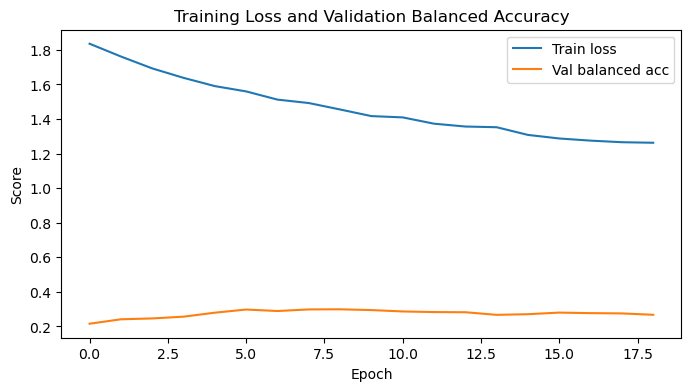

In [27]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_accs, label="Val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("Training Loss and Validation Balanced Accuracy")
plt.show()


In [34]:
# 7. Final Evaluation: Custom EEGNet on Test Set

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Ensure best model weights are loaded
model.load_state_dict(best_model_state_custom)

# Collect predictions and labels
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.cpu().numpy())

# Compute metrics
test_bal_acc = balanced_accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"Custom EEGNet - Test balanced accuracy: {test_bal_acc:.3f}")

# Plot confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=[1,2,3,4,5,6])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Custom EEGNet - Test Confusion Matrix")
plt.show()


RuntimeError: Error(s) in loading state_dict for EEGNet:
	Missing key(s) in state_dict: "firstconv.weight", "firstbn.weight", "firstbn.bias", "firstbn.running_mean", "firstbn.running_var", "depthwise.weight", "depthbn.weight", "depthbn.bias", "depthbn.running_mean", "depthbn.running_var", "separable.weight", "sepbn.weight", "sepbn.bias", "sepbn.running_mean", "sepbn.running_var", "classify.weight", "classify.bias". 
	Unexpected key(s) in state_dict: "conv_temporal.weight", "bnorm_temporal.weight", "bnorm_temporal.bias", "bnorm_temporal.running_mean", "bnorm_temporal.running_var", "bnorm_temporal.num_batches_tracked", "conv_spatial.weight", "bnorm_1.weight", "bnorm_1.bias", "bnorm_1.running_mean", "bnorm_1.running_var", "bnorm_1.num_batches_tracked", "conv_separable_depth.weight", "conv_separable_point.weight", "bnorm_2.weight", "bnorm_2.bias", "bnorm_2.running_mean", "bnorm_2.running_var", "bnorm_2.num_batches_tracked", "final_layer.conv_classifier.weight", "final_layer.conv_classifier

## 8. EEGNetv4 Reference Model (Braindecode)

To benchmark our approach, we now replace the custom EEGNet implementation with the canonical EEGNetv4 model provided by the [Braindecode](https://braindecode.org/) library. This architecture is widely used and well-tested for EEG decoding tasks. We train and evaluate this model using the same splits, normalisation, and class weights as before, enabling a direct comparison of results.

In [33]:
# 8.1. Instantiate EEGNetv4 from Braindecode

model_bc = EEGNetv4(
    n_outputs=6,
    n_chans=n_channels,
    n_times=window_samples,
    final_conv_length='auto'
).to(device)

print("Braindecode EEGNetv4 model instantiated.")


Braindecode EEGNetv4 model instantiated.


In [30]:
# 8.2. Test forward pass

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
with torch.no_grad():
    out = model_bc(x_batch)
print(f"EEGNetv4 output shape: {out.shape}")
print(f"First 5 logits:\n{out[:5]}")


EEGNetv4 output shape: torch.Size([64, 6])
First 5 logits:
tensor([[-0.1976, -0.1431, -0.3173, -0.6641,  0.3340, -0.1722],
        [-0.2415,  0.1206, -0.5853, -0.4233,  0.0620,  0.5106],
        [-0.1964,  0.5842, -0.9041, -0.5215,  0.5904, -0.1310],
        [ 0.0387,  0.0383, -0.2628,  0.0159, -0.0117,  0.3789],
        [-0.5657,  0.0375,  0.2631, -1.2272, -0.1340,  0.8340]])


In [31]:
# 8.3. Training and validation for EEGNetv4

optimizer = optim.Adam(model_bc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

num_epochs = 100
patience = 10
best_val_acc = 0
epochs_no_improve = 0
train_losses = []
val_accs = []
best_model_state_ac = deepcopy(model_bc.state_dict())

for epoch in range(num_epochs):
    model_bc.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_bc(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    val_acc = eval_model(model_bc, val_loader, device)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_ac = deepcopy(model_bc.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best val bal-acc={best_val_acc:.3f}")
        break

model_bc.load_state_dict(best_model_state_ac)
print("Best EEGNetv4 model loaded from validation.")


Epoch 1: Train loss=1.8551 | Val bal-acc=0.167
Epoch 2: Train loss=1.7989 | Val bal-acc=0.185
Epoch 3: Train loss=1.7826 | Val bal-acc=0.184
Epoch 4: Train loss=1.7603 | Val bal-acc=0.200
Epoch 5: Train loss=1.7423 | Val bal-acc=0.216
Epoch 6: Train loss=1.7247 | Val bal-acc=0.218
Epoch 7: Train loss=1.7038 | Val bal-acc=0.214
Epoch 8: Train loss=1.6850 | Val bal-acc=0.231
Epoch 9: Train loss=1.6649 | Val bal-acc=0.220
Epoch 10: Train loss=1.6482 | Val bal-acc=0.211
Epoch 11: Train loss=1.6308 | Val bal-acc=0.234
Epoch 12: Train loss=1.6166 | Val bal-acc=0.239
Epoch 13: Train loss=1.5855 | Val bal-acc=0.236
Epoch 14: Train loss=1.5739 | Val bal-acc=0.246
Epoch 15: Train loss=1.5576 | Val bal-acc=0.261
Epoch 16: Train loss=1.5345 | Val bal-acc=0.254
Epoch 17: Train loss=1.5279 | Val bal-acc=0.267
Epoch 18: Train loss=1.5130 | Val bal-acc=0.260
Epoch 19: Train loss=1.5122 | Val bal-acc=0.257
Epoch 20: Train loss=1.4938 | Val bal-acc=0.267
Epoch 21: Train loss=1.4836 | Val bal-acc=0.269
E

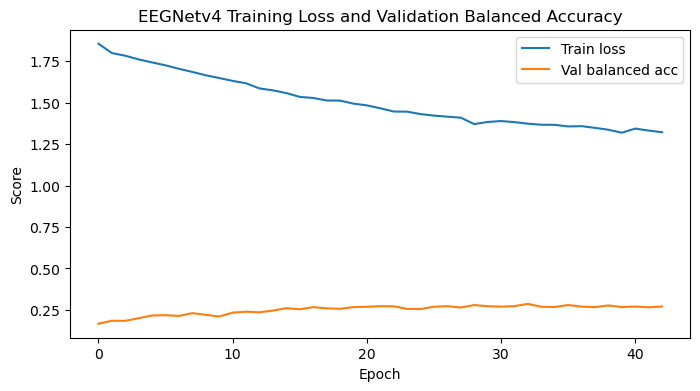

Final val bal-acc: 0.271


In [32]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_accs, label="Val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("EEGNetv4 Training Loss and Validation Balanced Accuracy")
plt.show()
print(f"Final val bal-acc: {val_accs[-1]:.3f}")


EEGNetv4 (Braindecode) - Test balanced accuracy: 0.345


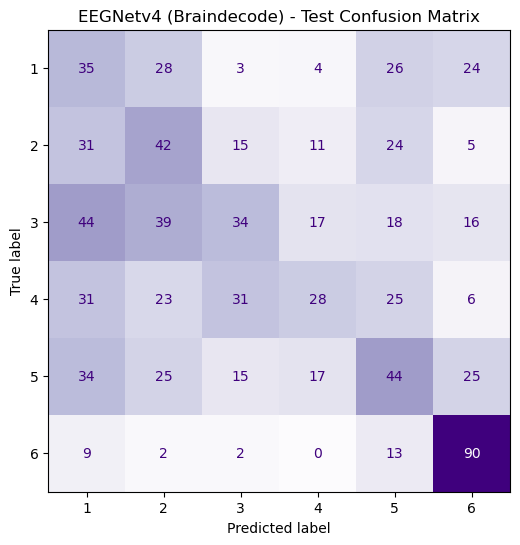

In [35]:
# 8. Final Evaluation: EEGNetv4 (Braindecode) on Test Set

# Ensure best model weights are loaded
model_bc.load_state_dict(best_model_state_ac)

# Collect predictions and labels
model_bc.eval()
all_preds_bc, all_labels_bc = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model_bc(xb)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds_bc.extend(preds)
        all_labels_bc.extend(yb.cpu().numpy())

# Compute metrics
test_bal_acc_bc = balanced_accuracy_score(all_labels_bc, all_preds_bc)
cm_bc = confusion_matrix(all_labels_bc, all_preds_bc)

print(f"EEGNetv4 (Braindecode) - Test balanced accuracy: {test_bal_acc_bc:.3f}")

# Plot confusion matrix
disp_bc = ConfusionMatrixDisplay(cm_bc, display_labels=[1,2,3,4,5,6])
fig, ax = plt.subplots(figsize=(6,6))
disp_bc.plot(ax=ax, cmap="Purples", colorbar=False)
plt.title("EEGNetv4 (Braindecode) - Test Confusion Matrix")
plt.show()
